In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!cp "/content/drive/MyDrive/archive.zip" "/content/"

In [3]:
!unzip -q "/content/archive.zip"

In [4]:
import os
print(os.listdir("/content/garbage_classification"))

['metal', 'green-glass', 'plastic', 'trash', 'white-glass', 'paper', 'cardboard', 'battery', 'biological', 'brown-glass', 'shoes', 'clothes']


# ✅ Step 1: Import Libraries and Set Paths


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

data_dir = "/content/garbage_classification"

image_height = 224
image_width = 224
batch_size = 64

# split train and test data

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(image_height,image_width),
    seed=12,
    validation_split=0.3,
    subset="training",
    batch_size=batch_size
)

Found 15515 files belonging to 12 classes.
Using 10861 files for training.


In [7]:
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(image_height,image_width),
    seed=12,
    validation_split =0.3,
    subset="validation",
    batch_size=batch_size
)

Found 15515 files belonging to 12 classes.
Using 4654 files for validation.


In [8]:
val_test_batch = int(0.5*len(val_test_ds))
val_ds=val_test_ds.take(val_test_batch)
test_ds=val_test_ds.skip(val_test_batch)

# ✅ Step 3:Exploratory Data Analysis (EDA)

#getting class names


In [9]:
class_names = train_ds.class_names
class_names

['battery',
 'biological',
 'brown-glass',
 'cardboard',
 'clothes',
 'green-glass',
 'metal',
 'paper',
 'plastic',
 'shoes',
 'trash',
 'white-glass']

#No.of images in each class

In [10]:
class_counts={}
for cls in os.listdir(data_dir):
  class_counts[cls]=len(os.listdir(os.path.join(data_dir,cls)))

for cls,counts in class_counts.items():
  print(f"{cls}:{counts}")

metal:769
green-glass:629
plastic:865
trash:697
white-glass:775
paper:1050
cardboard:891
battery:945
biological:985
brown-glass:607
shoes:1977
clothes:5325


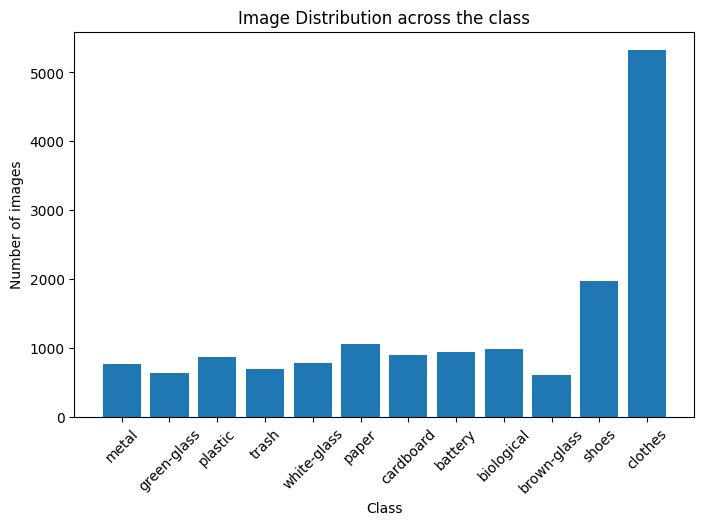

In [11]:
classes = list(class_counts.keys())
counts=list(class_counts.values())
plt.figure(figsize=(8,5))
plt.bar(classes,counts)
plt.title("Image Distribution across the class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.show()

The class clothes have nearly 2-2.5x more data compare to other classes

# Visualizing 5 images from the data set

In [ ]:
for i,(img,label) in enumerate(train_ds.take(6)):
  plt.subplot(2,3,i+1)
  plt.imshow(img[0].numpy().astype("uint8"))
  plt.title(class_names[label[0]])
  plt.axis("off")
plt.tight_layout()
plt.show()


#pixel intensity distribution

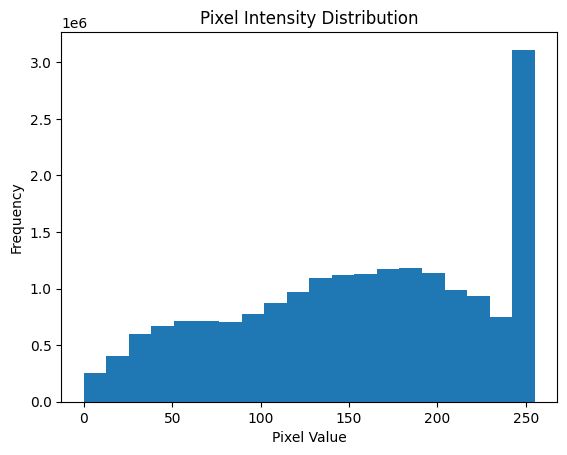

In [12]:
pixels = []
for images, labels in train_ds.take(2):
    pixels.extend(images.numpy().flatten())

plt.hist(pixels,bins=20)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

#Most pixel values fall between 230 and 250, suggesting that the images predominantly have light or white backgrounds, resulting in higher intensity values.

# ✅ Step 4:Preprocessing

#augmentation

In [ ]:
from tensorflow.keras import Sequential,layers

image_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1)
])

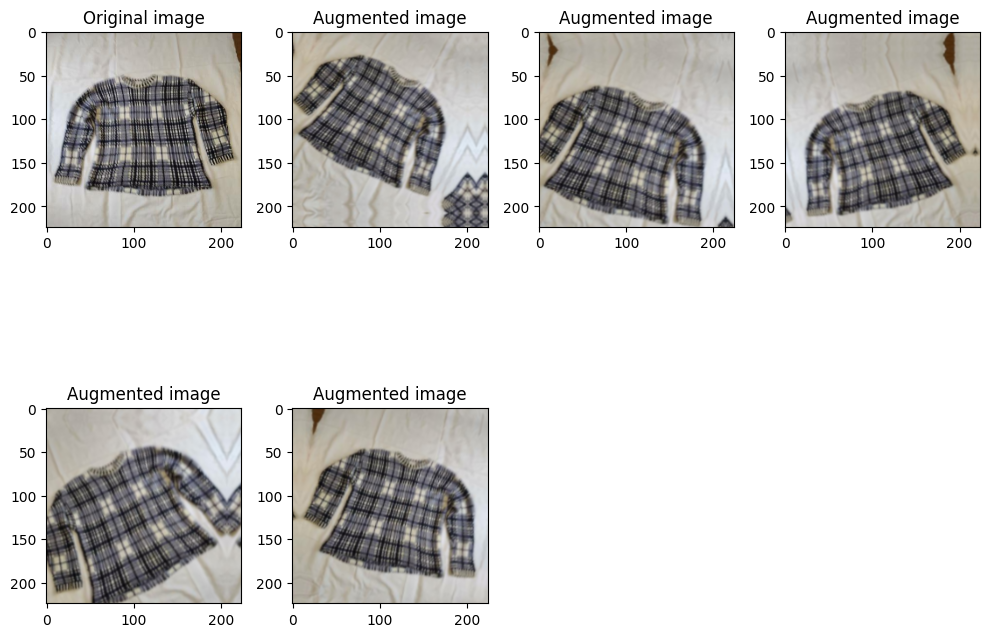

In [ ]:
for img,label in train_ds.take(1):
  original_image = img[0]
  plt.figure(figsize=(10,8))
  plt.subplot(2,4,1)
  plt.imshow(original_image.numpy().astype("uint8"))
  plt.title("Original image")
  # plt.axis("off")

  for i in range(5):
    augmented_image = image_augmentation(tf.expand_dims(original_image,0))
    plt.subplot(2,4,i+2)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.title("Augmented image")
    # plt.axis("off")

plt.tight_layout()
plt.show()



#compute class weights for data imbalance


To address class imbalance in the dataset, class weights were computed. Classes with a higher number of samples were assigned lower weights, while classes with fewer samples received higher weights. These weights are applied during model training to ensure the model does not become biased toward the majority classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
label =np.array([label.numpy() for _,label in train_ds.unbatch()])

class_weights = compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(label),
    y=label
)

class_weights = dict(enumerate(class_weights))

In [ ]:
for label,weight in class_weights.items():
  print(f"{label}:{class_names[label]}:{weight}")

0:battery:1.3881646216768917
1:biological:1.3488574267262792
2:brown-glass:2.268379281537176
3:cardboard:1.4740770901194353
4:clothes:0.24161327638369817
5:green-glass:2.119633099141296
6:metal:1.6698954489544895
7:paper:1.1678494623655915
8:plastic:1.4984823399558498
9:shoes:0.6382816173013635
10:trash:1.950610632183908
11:white-glass:1.6486035215543413


Model building

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
autotune = tf.data.AUTOTUNE
train_ds=train_ds.cache().shuffle(1000).prefetch(autotune)
val_ds=val_ds.cache().prefetch(autotune)
test_ds=test_ds.cache().prefetch(autotune)

In [ ]:
def build_model(base_model,preprocess_fn):
  base_model.trainable=False

  inputs=tf.keras.Input(shape=(224,224,3))
  x=image_augmentation(inputs)
  x=preprocess_fn(x)
  x=base_model(x,training=False)
  x=GlobalAveragePooling2D()(x)
  x=BatchNormalization()(x)
  x=Dense(128,activation="relu")(x)
  x=Dropout(0.3)(x)
  outputs=Dense(12,activation="softmax")(x)
  model=Model(inputs,outputs,dtype="float32")

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
  )

  return model


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

mobilenet_base=MobileNetV2(
    input_shape=(224,224,3),
    weights="imagenet",
    include_top=False

)
efficient_base=EfficientNetB0(
     input_shape=(224,224,3),
    weights="imagenet",
    include_top=False
)

mobilenet_model = build_model(mobilenet_base,mobilenet_preprocess)
efficient_model=build_model(efficient_base,efficientnet_preprocess)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [ ]:
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/12
111/170 ━━━━━━━━━━━━━━━━━━━━ 3:33 4s/step - accuracy: 0.6624 - loss: 1.3262

In [ ]:
efficient_history=efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights,
    callbacks=[early_stop]
)

In [ ]:
mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Fine tune the model by making first 30 layers of the base model trainable

In [ ]:
efficient_base.trainable = True

for layer in efficient_base.layers[:-30]:
    layer.trainable = False

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

In [ ]:
import seaborn as sns
y_true = np.concatenate([y for x, y in test_ds], axis=0)
def evaluate_model(model, test_ds, y_true):

    y_pred_prob = model.predict(test_ds)

    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    cm = confusion_matrix(y_true, y_pred)

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    plt.figure(figsize=(10,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_ds.class_names,
            yticklabels=test_ds.class_names)

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return f1

Displaying result for both Models

In [ ]:
print("MobileNet Results")
mobilenet_f1 = evaluate_model(mobilenet_model, test_ds, y_true)

In [ ]:
print("EfficientNet Results")
efficientnet_f1 = evaluate_model(efficient_model, test_ds, y_true)

for displaying the results to compare between two models

In [ ]:
mobilenet_pred = np.argmax(mobilenet_model.predict(test_ds), axis=1)
efficient_pred = np.argmax(efficient_model.predict(test_ds), axis=1)

mobilenet_acc = accuracy_score(y_true, mobilenet_pred)
efficient_acc = accuracy_score(y_true, efficient_pred)

mobilenet_f1 = f1_score(y_true, mobilenet_pred, average="weighted")
efficient_f1 = f1_score(y_true, efficient_pred, average="weighted")

In [ ]:
results=pd.DataFrame(
    {
    "Model": [ "MobileNet", "EfficientNet"],
    "Accuracy": [ mobilenet_acc, efficient_acc],
    "F1 Score": [ mobilenet_f1, efficient_f1]
}
)
results

In [ ]:
if mobilenet_f1 >= efficient_f1:
  mobilenet_model.save("garbage_classification_model.h5")
else:
  efficient_model.save("garbage_classification_model.h5")

Create json file named class_names for saving the class_names

In [ ]:
import json

class_names = train_ds.class_names

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [ ]:
from google.colab import files

files.download("garbage_classification_model.h5")
files.download("class_names.json")